# Unsupervised Anomaly Detection on SMD

This notebook compares two unsupervised anomaly detection methods on the Server Machine Dataset (SMD), using `machine-1-1`.

We compare:

1. a convolutional autoencoder trained only on normal training windows;
2. MOMENT, a pretrained time-series foundation model used in zero-shot mode, without fine-tuning.

For both methods, the anomaly score is the reconstruction error. The training set is used only as normal data. Test labels are used only for evaluation.

## 1. Setup

Run this notebook on Google Colab with GPU enabled:

`Runtime > Change runtime type > GPU`

MOMENT is large, so the zero-shot part can take time even on a Tesla T4.

In [45]:
# Force Transformers to ignore TensorFlow/JAX.
# This avoids unnecessary TensorFlow-related dependency issues.
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

!pip install -q numpy pandas scikit-learn matplotlib tqdm
!pip install -q "git+https://github.com/moment-timeseries-foundation-model/moment.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [46]:
import random
import subprocess
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from momentfm import MOMENTPipeline

SEED = 2026

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device type:", device)

Device type: cuda


## 2. Data loading

We download the OmniAnomaly repository and load the SMD machine `machine-1-1`.

The train file contains normal data only. The test file contains normal and anomalous timestamps. The labels are available only for the test set.

In [47]:
REPO_URL = "https://github.com/NetManAIOps/OmniAnomaly.git"
REPO_DIR = Path("OmniAnomaly")
SMD_ROOT = REPO_DIR / "ServerMachineDataset"
MACHINE = "machine-1-1"

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL], check=True)

train_path = SMD_ROOT / "train" / f"{MACHINE}.txt"
test_path = SMD_ROOT / "test" / f"{MACHINE}.txt"
label_path = SMD_ROOT / "test_label" / f"{MACHINE}.txt"

X_train = np.loadtxt(train_path, delimiter=",").astype(np.float32)
X_test = np.loadtxt(test_path, delimiter=",").astype(np.float32)
y_test = np.loadtxt(label_path, delimiter=",").astype(int)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Anomaly ratio in test:", y_test.mean())

X_train: (28479, 38)
X_test : (28479, 38)
y_test : (28479,)
Anomaly ratio in test: 0.09459601811861372


First anomaly index: 15849
Last anomaly index : 27555
Number of anomalous timestamps: 2694


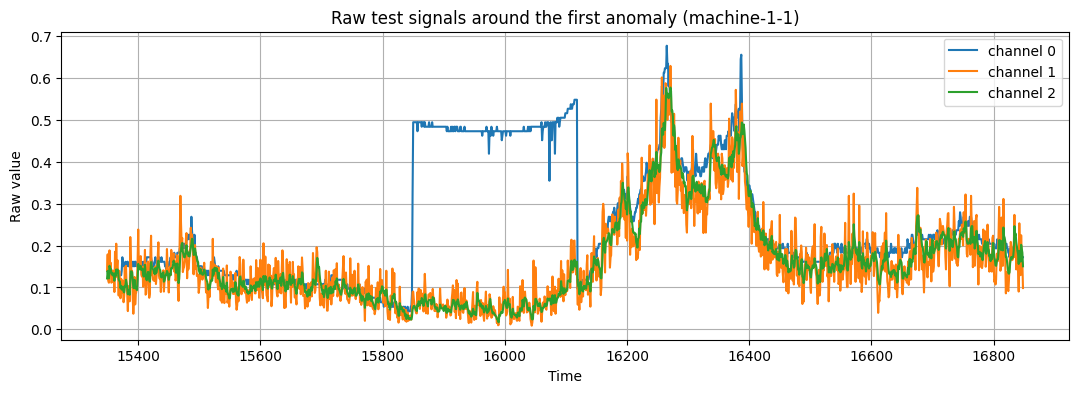

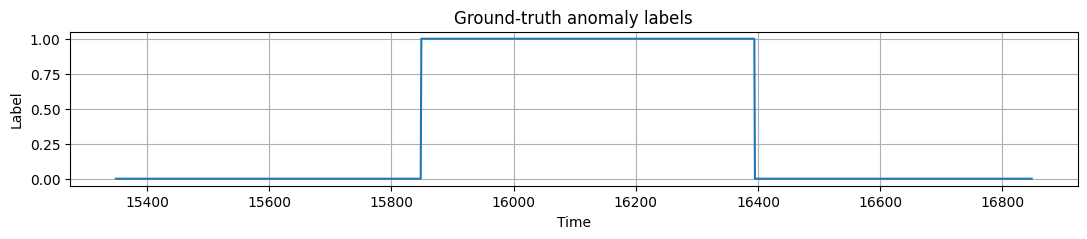

In [48]:
anomaly_indices = np.where(y_test == 1)[0]

print("First anomaly index:", anomaly_indices[0])
print("Last anomaly index :", anomaly_indices[-1])
print("Number of anomalous timestamps:", len(anomaly_indices))

start = anomaly_indices[0] - 500
end = anomaly_indices[0] + 1000

plt.figure(figsize=(13, 4))
for c in range(3):
    plt.plot(np.arange(start, end), X_test[start:end, c], label=f"channel {c}")
plt.title(f"Raw test signals around the first anomaly ({MACHINE})")
plt.xlabel("Time")
plt.ylabel("Raw value")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(13, 2))
plt.plot(np.arange(start, end), y_test[start:end])
plt.title("Ground-truth anomaly labels")
plt.xlabel("Time")
plt.ylabel("Label")
plt.grid(True)
plt.show()

## 3. Train-only preprocessing

Each channel is standardized using only the training data. This avoids information leakage from the test set.

In [49]:
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)
std_train[std_train == 0] = 1.0

X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train

print("Mean of first 5 train channels after scaling:")
print(X_train_scaled.mean(axis=0)[:5])
print("Std of first 5 train channels after scaling:")
print(X_train_scaled.std(axis=0)[:5])

Mean of first 5 train channels after scaling:
[-6.6546163e-05 -2.2603847e-06 -1.6474105e-07  1.2135002e-05
  0.0000000e+00]
Std of first 5 train channels after scaling:
[1.0000267 1.0000108 0.9999971 1.0000058 0.       ]


## 4. Windowing and statistical thresholding setup

Both models operate on fixed-length windows rather than isolated timestamps. This is necessary because the anomaly score is based on reconstruction of a short temporal context, not on a single point.

We use windows of length 96 for both the autoencoder and MOMENT. This keeps the two methods comparable and is compatible with MOMENT reconstruction mode.

The training data is split chronologically at the raw time-series level into:

- a fitting part, used to train the autoencoder;
- a held-out normal calibration part, used only to set the anomaly threshold.

The stride has two different roles:

- the training stride controls how many overlapping windows are used for optimization;
- the calibration and test strides control the resolution at which anomaly scores are calibrated and evaluated.

For maximum consistency of the thresholding step, calibration and test use the same stride: `stride = 1`. This means the threshold is calibrated on dense normal windows and then applied to dense test windows with the same extraction rule.

The training stride can be larger than 1 as a computational compromise, because it only affects optimization. If compute allows it, setting the training stride to 1 is the most uniform choice.

Since the original SMD labels are timestamp-level labels, we report both:

- window-level metrics, because the models naturally output one score per window;
- timestamp-level AUROC/AUPRC, obtained by averaging the scores of all windows covering each timestamp.

The binary threshold is not chosen by maximizing F1 on test labels. Instead, we define a statistical false-alarm objective before evaluation: a global false-alarm probability budget over the test horizon. This budget is converted into a per-window tail probability, and the threshold is estimated from held-out normal calibration scores using a non-parametric conformal quantile rule.


In [50]:
def create_windows(X, window_size, stride):
    windows = []
    starts = []
    for start in range(0, len(X) - window_size + 1, stride):
        windows.append(X[start:start + window_size])
        starts.append(start)
    return np.array(windows, dtype=np.float32), np.array(starts)


def create_window_labels(y, starts, window_size):
    return np.array([y[s:s + window_size].max() for s in starts], dtype=int)


def window_scores_to_timestamps(scores, starts, window_size, length):
    timestamp_scores = np.zeros(length, dtype=np.float32)
    counts = np.zeros(length, dtype=np.float32)

    for score, start in zip(scores, starts):
        timestamp_scores[start:start + window_size] += score
        counts[start:start + window_size] += 1

    counts[counts == 0] = 1
    return timestamp_scores / counts


def conformal_quantile_threshold(calibration_scores, alpha):
    """
    Non-parametric split-conformal quantile threshold.

    alpha is the target upper-tail probability for a normal window.
    A smaller alpha gives a more conservative threshold.
    """
    scores = np.sort(np.asarray(calibration_scores))
    n = len(scores)

    if n == 0:
        raise ValueError("Calibration scores are empty.")
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0, 1).")

    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    return scores[k - 1]


def per_window_alpha_from_global_budget(n_test_windows, global_false_alarm_probability):
    """
    Bonferroni-style conversion from a global false-alarm probability budget
    over the full test horizon to a per-window tail probability.

    If P(normal window exceeds threshold) <= alpha, then by the union bound,
    P(at least one false alarm over n_test_windows) <= n_test_windows * alpha.
    """
    if n_test_windows <= 0:
        raise ValueError("n_test_windows must be positive.")
    if not (0 < global_false_alarm_probability < 1):
        raise ValueError("global_false_alarm_probability must be in (0, 1).")

    return global_false_alarm_probability / n_test_windows


In [51]:
# Window extraction parameters
WINDOW_AE = 96
STRIDE_TRAIN_AE = 1
STRIDE_CALIB_AE = 1       # must match test stride for threshold calibration
STRIDE_TEST_AE = 1        # dense scores for timestamp-level evaluation

CALIBRATION_FRACTION = 0.2
split_time_ae = int((1 - CALIBRATION_FRACTION) * len(X_train_scaled))

X_fit_scaled_ae = X_train_scaled[:split_time_ae]
X_calib_scaled_ae = X_train_scaled[split_time_ae:]

X_fit_win_ae, fit_starts_ae = create_windows(X_fit_scaled_ae, WINDOW_AE, STRIDE_TRAIN_AE)
X_calib_win_ae, calib_starts_ae = create_windows(X_calib_scaled_ae, WINDOW_AE, STRIDE_CALIB_AE)
X_test_win_ae, test_starts_ae = create_windows(X_test_scaled, WINDOW_AE, STRIDE_TEST_AE)
y_test_win_ae = create_window_labels(y_test, test_starts_ae, WINDOW_AE)

print("Autoencoder windows")
print("X_fit_win_ae  :", X_fit_win_ae.shape, "stride =", STRIDE_TRAIN_AE)
print("X_calib_win_ae:", X_calib_win_ae.shape, "stride =", STRIDE_CALIB_AE)
print("X_test_win_ae :", X_test_win_ae.shape, "stride =", STRIDE_TEST_AE)
print("Anomaly ratio :", y_test_win_ae.mean())


Autoencoder windows
X_fit_win_ae  : (22688, 96, 38) stride = 1
X_calib_win_ae: (5601, 96, 38) stride = 1
X_test_win_ae : (28384, 96, 38) stride = 1
Anomaly ratio : 0.12168827508455468


## 5. Method 1 — Convolutional autoencoder

The autoencoder is trained only on normal fitting windows.

The held-out calibration segment is also normal, but it is not used for gradient updates. It is used only to estimate the distribution of reconstruction scores under normal behavior and to set the binary anomaly threshold.

The anomaly score is the mean squared reconstruction error over all timestamps and channels.


In [52]:
BATCH_SIZE_AE = 128

X_fit_torch_ae = torch.tensor(X_fit_win_ae.transpose(0, 2, 1), dtype=torch.float32)
X_calib_torch_ae = torch.tensor(X_calib_win_ae.transpose(0, 2, 1), dtype=torch.float32)
X_test_torch_ae = torch.tensor(X_test_win_ae.transpose(0, 2, 1), dtype=torch.float32)

g = torch.Generator()
g.manual_seed(SEED)

fit_loader_ae = DataLoader(
    TensorDataset(X_fit_torch_ae),
    batch_size=BATCH_SIZE_AE,
    shuffle=True,
    generator=g
)


calib_loader_ae = DataLoader(
    TensorDataset(X_calib_torch_ae),
    batch_size=BATCH_SIZE_AE,
    shuffle=False,
)

test_loader_ae = DataLoader(
    TensorDataset(X_test_torch_ae),
    batch_size=BATCH_SIZE_AE,
    shuffle=False,
)

print("AE fit windows        :", X_fit_win_ae.shape)
print("AE calibration windows:", X_calib_win_ae.shape)
print("AE test windows       :", X_test_win_ae.shape)


AE fit windows        : (22688, 96, 38)
AE calibration windows: (5601, 96, 38)
AE test windows       : (28384, 96, 38)


Training autoencoder:   0%|          | 0/50 [00:00<?, ?it/s]

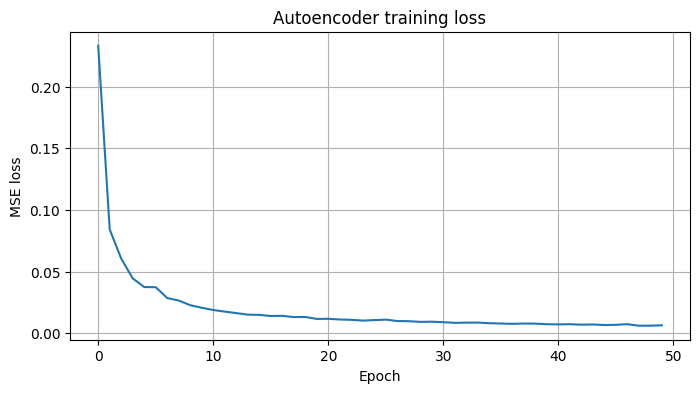

In [53]:
class ConvAutoencoder(nn.Module):
    def __init__(self, n_channels):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, n_channels, kernel_size=7, padding=3),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


ae_model = ConvAutoencoder(n_channels=X_fit_torch_ae.shape[1]).to(device)

EPOCHS = 50
LR = 1e-3

optimizer = torch.optim.Adam(ae_model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []

for epoch in tqdm(range(EPOCHS), desc="Training autoencoder"):
    ae_model.train()
    losses = []

    for (x,) in fit_loader_ae:
        x = x.to(device)

        optimizer.zero_grad()
        x_hat = ae_model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    train_losses.append(np.mean(losses))

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Autoencoder training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

In [57]:
def reconstruction_scores(model, loader):
    model.eval()
    scores = []

    with torch.inference_mode():
        for (x,) in loader:
            x = x.to(device)
            x_hat = model(x)
            score = ((x - x_hat) ** 2).mean(dim=(1, 2))
            scores.append(score.cpu().numpy())

    return np.concatenate(scores)


# Reconstruction scores
ae_calib_scores = reconstruction_scores(ae_model, calib_loader_ae)
ae_test_scores = reconstruction_scores(ae_model, test_loader_ae)


# Window-level threshold-free metrics
ae_auroc_window = roc_auc_score(y_test_win_ae, ae_test_scores)
ae_auprc_window = average_precision_score(y_test_win_ae, ae_test_scores)


# Timestamp-level threshold-free metrics
ae_test_scores_time = window_scores_to_timestamps(
    scores=ae_test_scores,
    starts=test_starts_ae,
    window_size=WINDOW_AE,
    length=len(y_test)
)

ae_auroc_time = roc_auc_score(y_test, ae_test_scores_time)
ae_auprc_time = average_precision_score(y_test, ae_test_scores_time)


# threshold selection
# We choose a global false-alarm probability budget over the whole test horizon.
# This is converted into a per-window tail probability using a union-bound argument.
GLOBAL_FALSE_ALARM_PROBABILITY = 0.05

n_test_windows_ae = len(ae_test_scores)
ae_alpha_per_window = per_window_alpha_from_global_budget(
    n_test_windows=n_test_windows_ae,
    global_false_alarm_probability=GLOBAL_FALSE_ALARM_PROBABILITY,
)
ae_threshold_percentile = 100 * (1 - ae_alpha_per_window)

ae_threshold = conformal_quantile_threshold(ae_calib_scores, alpha=ae_alpha_per_window)
ae_pred = (ae_test_scores > ae_threshold).astype(int)

print("AE statistical thresholding")
print("Global false-alarm probability budget:", GLOBAL_FALSE_ALARM_PROBABILITY)
print("Number of test windows:", n_test_windows_ae)
print("Per-window alpha:", ae_alpha_per_window)
print("Equivalent percentile:", ae_threshold_percentile)
print("Threshold:", ae_threshold)


# Window-level binary metrics at the fixed threshold
ae_precision = precision_score(y_test_win_ae, ae_pred, zero_division=0)
ae_recall = recall_score(y_test_win_ae, ae_pred, zero_division=0)
ae_f1 = f1_score(y_test_win_ae, ae_pred, zero_division=0)
ae_tn, ae_fp, ae_fn, ae_tp = confusion_matrix(y_test_win_ae, ae_pred, labels=[0, 1]).ravel()


ae_results = pd.DataFrame([{
    "Method": "Conv Autoencoder",
    "Window size": WINDOW_AE,
    "Train stride": STRIDE_TRAIN_AE,
    "Calibration stride": STRIDE_CALIB_AE,
    "Test stride": STRIDE_TEST_AE,
    "Global false alarm probability": GLOBAL_FALSE_ALARM_PROBABILITY,
    "Per-window alpha": ae_alpha_per_window,
    "Equivalent threshold percentile": ae_threshold_percentile,
    "Threshold": ae_threshold,
    "AUROC window": ae_auroc_window,
    "AUPRC window": ae_auprc_window,
    "AUROC timestamp": ae_auroc_time,
    "AUPRC timestamp": ae_auprc_time,
    "Precision window": ae_precision,
    "Recall window": ae_recall,
    "F1 window": ae_f1,
    "TN": ae_tn,
    "FP": ae_fp,
    "FN": ae_fn,
    "TP": ae_tp,
}])

display(ae_results)


AE statistical thresholding
Global false-alarm probability budget: 0.05
Number of test windows: 28384
Per-window alpha: 1.761555806087937e-06
Equivalent percentile: 99.99982384441938
Threshold: 0.062460195


,Method,Window size,Train stride,Calibration stride,Test stride,Global false alarm probability,Per-window alpha,Equivalent threshold percentile,Threshold,AUROC window,AUPRC window,AUROC timestamp,AUPRC timestamp,Precision window,Recall window,F1 window,TN,FP,FN,TP
0,Conv Autoencoder,96,1,1,1,0.05,0.000002,99.999824,0.06246,0.959592,0.836565,0.965563,0.750775,0.220435,1.0,0.36124,12715,12215,0,3454


### Threshold sensitivity analysis

The final binary threshold used for reporting is fixed in advance from the held-out normal calibration scores, using the statistical false-alarm rule defined above. It is not selected with the test labels.

The sensitivity analysis below varies the calibration-score percentile only to diagnose the precision-recall trade-off. It is not used to choose the final threshold.

The vertical dashed line corresponds to the percentile implied by the global false-alarm probability budget.

Since the reconstruction-error distribution is highly skewed, the score histogram is shown in log scale using `log(1 + score)`.


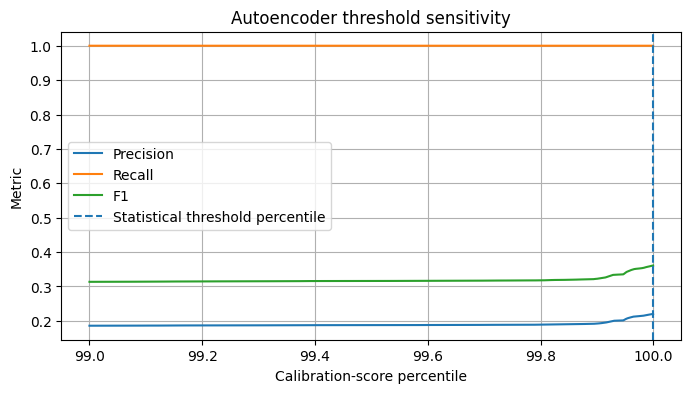

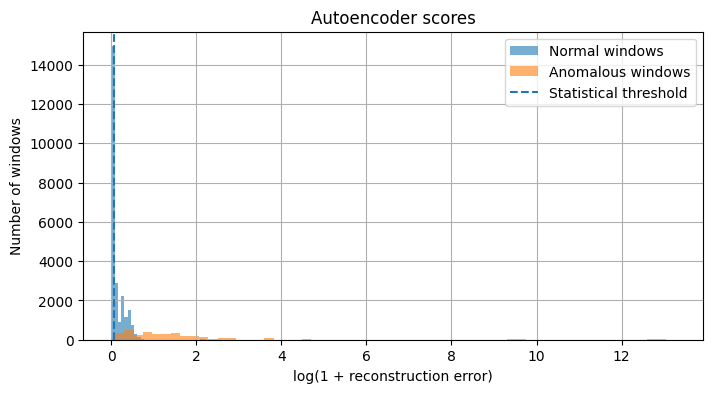

In [58]:
# Threshold sensitivity analysis
percentiles = np.arange(99, 99.99991, 0.0005)
rows = []

for p in percentiles:
    threshold = np.percentile(ae_calib_scores, p)
    pred = (ae_test_scores > threshold).astype(int)

    precision = precision_score(y_test_win_ae, pred, zero_division=0)
    recall = recall_score(y_test_win_ae, pred, zero_division=0)
    f1 = f1_score(y_test_win_ae, pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test_win_ae, pred, labels=[0, 1]).ravel()

    rows.append({
        "Percentile": p,
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

ae_threshold_df = pd.DataFrame(rows)


plt.figure(figsize=(8, 4))
plt.plot(ae_threshold_df["Percentile"], ae_threshold_df["Precision"], label="Precision")
plt.plot(ae_threshold_df["Percentile"], ae_threshold_df["Recall"], label="Recall")
plt.plot(ae_threshold_df["Percentile"], ae_threshold_df["F1"], label="F1")
plt.axvline(ae_threshold_percentile, linestyle="--", label="Statistical threshold percentile")
plt.title("Autoencoder threshold sensitivity")
plt.xlabel("Calibration-score percentile")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()


normal_ae = ae_test_scores[y_test_win_ae == 0]
anomaly_ae = ae_test_scores[y_test_win_ae == 1]

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(normal_ae), bins=60, alpha=0.6, label="Normal windows")
plt.hist(np.log1p(anomaly_ae), bins=60, alpha=0.6, label="Anomalous windows")
plt.axvline(np.log1p(ae_threshold), linestyle="--", label="Statistical threshold")
plt.title("Autoencoder scores")
plt.xlabel("log(1 + reconstruction error)")
plt.ylabel("Number of windows")
plt.legend()
plt.grid(True)
plt.show()


In [59]:
ae_threshold_df

,Percentile,Threshold,Precision,Recall,F1,TN,FP,FN,TP
0,99.0000,0.040671,0.185899,1.0,0.313515,9804,15126,0,3454
1,99.0005,0.040672,0.185899,1.0,0.313515,9804,15126,0,3454
2,99.0010,0.040673,0.185899,1.0,0.313515,9804,15126,0,3454
3,99.0015,0.040675,0.185909,1.0,0.313530,9805,15125,0,3454
4,99.0020,0.040676,0.185919,1.0,0.313544,9806,15124,0,3454
...,...,...,...,...,...,...,...,...,...
1995,99.9975,0.061892,0.219720,1.0,0.360280,12664,12266,0,3454
1996,99.9980,0.062006,0.219832,1.0,0.360430,12672,12258,0,3454
1997,99.9985,0.062119,0.220070,1.0,0.360750,12689,12241,0,3454
1998,99.9990,0.062233,0.220168,1.0,0.360882,12696,12234,0,3454


## 6. Method 2 — MOMENT zero-shot

MOMENT is used as a frozen pretrained foundation model. We do not update its parameters. The anomaly score is again the reconstruction error.

In [38]:
moment_model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={"task_name": "reconstruction"},
)

moment_model.init()
moment_model = moment_model.to(device)
moment_model.eval()

for p in moment_model.parameters():
    p.requires_grad = False

print("MOMENT parameters frozen:", all(not p.requires_grad for p in moment_model.parameters()))

MOMENT parameters frozen: True


In [39]:
# MOMENT windows
WINDOW_MOMENT = 96
STRIDE_CALIB_MOMENT = 1
STRIDE_TEST_MOMENT = 1

# MOMENT is not trained here, so there is no optimization stride.
# We use the same held-out raw calibration segment and the same dense stride as for the autoencoder.
X_calib_win_moment, calib_starts_moment = create_windows(X_calib_scaled_ae, WINDOW_MOMENT, STRIDE_CALIB_MOMENT)
X_test_win_moment, test_starts_moment = create_windows(X_test_scaled, WINDOW_MOMENT, STRIDE_TEST_MOMENT)
y_test_win_moment = create_window_labels(y_test, test_starts_moment, WINDOW_MOMENT)

X_calib_torch_moment = torch.tensor(X_calib_win_moment.transpose(0, 2, 1), dtype=torch.float32)
X_test_torch_moment = torch.tensor(X_test_win_moment.transpose(0, 2, 1), dtype=torch.float32)

BATCH_SIZE_MOMENT = 128

calib_loader_moment = DataLoader(
    TensorDataset(X_calib_torch_moment),
    batch_size=BATCH_SIZE_MOMENT,
    shuffle=False,
)

test_loader_moment = DataLoader(
    TensorDataset(X_test_torch_moment),
    batch_size=BATCH_SIZE_MOMENT,
    shuffle=False,
)

print("MOMENT windows")
print("X_calib_win_moment:", X_calib_win_moment.shape, "stride =", STRIDE_CALIB_MOMENT)
print("X_test_win_moment :", X_test_win_moment.shape, "stride =", STRIDE_TEST_MOMENT)
print("Anomaly ratio      :", y_test_win_moment.mean())
print("Calibration batches:", len(calib_loader_moment))
print("Test batches       :", len(test_loader_moment))


MOMENT windows
X_calib_win_moment: (5601, 96, 38) stride = 1
X_test_win_moment : (28384, 96, 38) stride = 1
Anomaly ratio      : 0.12168827508455468
Calibration batches: 44
Test batches       : 222


In [40]:
def moment_scores(model, loader, name):
    model.eval()
    scores = []
    start = time.time()

    with torch.inference_mode():
        for (x,) in tqdm(loader, desc=name):
            x = x.to(device)
            batch_size, _, seq_len = x.shape

            input_mask = torch.ones(batch_size, seq_len, device=device)

            output = model(x_enc=x, input_mask=input_mask)
            x_hat = output.reconstruction

            score = ((x - x_hat) ** 2).mean(dim=(1, 2))
            scores.append(score.cpu().numpy())

    scores = np.concatenate(scores)
    print(f"{name} finished in {(time.time() - start) / 60:.2f} min")
    return scores


moment_calib_scores = moment_scores(moment_model, calib_loader_moment, "MOMENT calibration")
moment_test_scores = moment_scores(moment_model, test_loader_moment, "MOMENT test")

MOMENT calibration:   0%|          | 0/44 [00:00<?, ?it/s]

MOMENT calibration finished in 10.42 min


MOMENT test:   0%|          | 0/222 [00:00<?, ?it/s]

MOMENT test finished in 52.64 min


### MOMENT thresholding and sensitivity analysis

MOMENT is used zero-shot, so no training split is needed for optimization. However, the binary threshold is still calibrated on the same held-out normal calibration segment used for the autoencoder.

The same statistical false-alarm rule is used: a global false-alarm probability budget over the test horizon is converted into a per-window tail probability, and the threshold is estimated from normal calibration scores.

The sensitivity analysis below is diagnostic only. It is not used to select the final threshold.


In [41]:
# Window-level threshold-free metrics
moment_auroc_window = roc_auc_score(y_test_win_moment, moment_test_scores)
moment_auprc_window = average_precision_score(y_test_win_moment, moment_test_scores)


# Timestamp-level threshold-free metrics
moment_test_scores_time = window_scores_to_timestamps(
    scores=moment_test_scores,
    starts=test_starts_moment,
    window_size=WINDOW_MOMENT,
    length=len(y_test)
)

moment_auroc_time = roc_auc_score(y_test, moment_test_scores_time)
moment_auprc_time = average_precision_score(y_test, moment_test_scores_time)


# Statistical threshold selection
# Same global false-alarm probability budget as for the autoencoder.
n_test_windows_moment = len(moment_test_scores)
moment_alpha_per_window = per_window_alpha_from_global_budget(
    n_test_windows=n_test_windows_moment,
    global_false_alarm_probability=GLOBAL_FALSE_ALARM_PROBABILITY,
)
moment_threshold_percentile = 100 * (1 - moment_alpha_per_window)

moment_threshold = conformal_quantile_threshold(moment_calib_scores, alpha=moment_alpha_per_window)
moment_pred = (moment_test_scores > moment_threshold).astype(int)

print("MOMENT statistical thresholding")
print("Global false-alarm probability budget:", GLOBAL_FALSE_ALARM_PROBABILITY)
print("Number of test windows:", n_test_windows_moment)
print("Per-window alpha:", moment_alpha_per_window)
print("Equivalent percentile:", moment_threshold_percentile)
print("Threshold:", moment_threshold)


# Window-level binary metrics at the fixed threshold
moment_precision = precision_score(y_test_win_moment, moment_pred, zero_division=0)
moment_recall = recall_score(y_test_win_moment, moment_pred, zero_division=0)
moment_f1 = f1_score(y_test_win_moment, moment_pred, zero_division=0)

moment_tn, moment_fp, moment_fn, moment_tp = confusion_matrix(
    y_test_win_moment,
    moment_pred,
    labels=[0, 1]
).ravel()


moment_results = pd.DataFrame([{
    "Method": "MOMENT zero-shot",
    "Window size": WINDOW_MOMENT,
    "Train stride": "N/A",
    "Calibration stride": STRIDE_CALIB_MOMENT,
    "Test stride": STRIDE_TEST_MOMENT,
    "Global false alarm probability": GLOBAL_FALSE_ALARM_PROBABILITY,
    "Per-window alpha": moment_alpha_per_window,
    "Equivalent threshold percentile": moment_threshold_percentile,
    "Threshold": moment_threshold,
    "AUROC window": moment_auroc_window,
    "AUPRC window": moment_auprc_window,
    "AUROC timestamp": moment_auroc_time,
    "AUPRC timestamp": moment_auprc_time,
    "Precision window": moment_precision,
    "Recall window": moment_recall,
    "F1 window": moment_f1,
    "TN": moment_tn,
    "FP": moment_fp,
    "FN": moment_fn,
    "TP": moment_tp,
}])

display(moment_results)


MOMENT statistical thresholding
Global false-alarm probability budget: 0.05
Number of test windows: 28384
Per-window alpha: 1.761555806087937e-06
Equivalent percentile: 99.99982384441938
Threshold: 1.7406323


,Method,Window size,Train stride,Calibration stride,Test stride,Global false alarm probability,Per-window alpha,Equivalent threshold percentile,Threshold,AUROC window,AUPRC window,AUROC timestamp,AUPRC timestamp,Precision window,Recall window,F1 window,TN,FP,FN,TP
0,MOMENT zero-shot,96,N/A,1,1,0.05,0.000002,99.999824,1.740632,0.969745,0.839114,0.973933,0.731681,0.855566,0.785466,0.819019,24472,458,741,2713


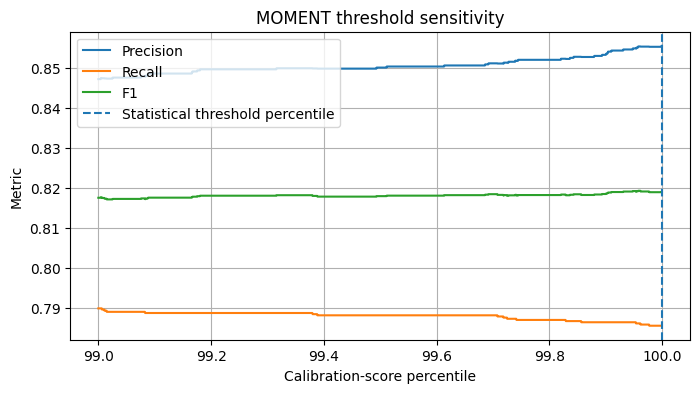

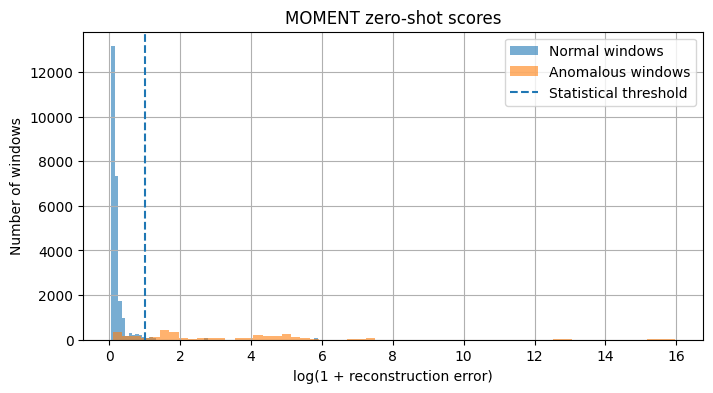

In [42]:
# Threshold sensitivity analysis
percentiles = np.arange(99, 99.99991, 0.0005)
rows = []

for p in percentiles:
    threshold = np.percentile(moment_calib_scores, p)
    pred = (moment_test_scores > threshold).astype(int)

    precision = precision_score(y_test_win_moment, pred, zero_division=0)
    recall = recall_score(y_test_win_moment, pred, zero_division=0)
    f1 = f1_score(y_test_win_moment, pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test_win_moment, pred, labels=[0, 1]).ravel()

    rows.append({
        "Percentile": p,
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

moment_threshold_df = pd.DataFrame(rows)


plt.figure(figsize=(8, 4))
plt.plot(moment_threshold_df["Percentile"], moment_threshold_df["Precision"], label="Precision")
plt.plot(moment_threshold_df["Percentile"], moment_threshold_df["Recall"], label="Recall")
plt.plot(moment_threshold_df["Percentile"], moment_threshold_df["F1"], label="F1")
plt.axvline(moment_threshold_percentile, linestyle="--", label="Statistical threshold percentile")
plt.title("MOMENT threshold sensitivity")
plt.xlabel("Calibration-score percentile")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()


normal_moment = moment_test_scores[y_test_win_moment == 0]
anomaly_moment = moment_test_scores[y_test_win_moment == 1]

plt.figure(figsize=(8, 4))
plt.hist(np.log1p(normal_moment), bins=60, alpha=0.6, label="Normal windows")
plt.hist(np.log1p(anomaly_moment), bins=60, alpha=0.6, label="Anomalous windows")
plt.axvline(np.log1p(moment_threshold), linestyle="--", label="Statistical threshold")
plt.title("MOMENT zero-shot scores")
plt.xlabel("log(1 + reconstruction error)")
plt.ylabel("Number of windows")
plt.legend()
plt.grid(True)
plt.show()


In [60]:
final_results = pd.concat([ae_results, moment_results], ignore_index=True)
display(final_results)

,Method,Window size,Train stride,Calibration stride,Test stride,Global false alarm probability,Per-window alpha,Equivalent threshold percentile,Threshold,AUROC window,AUPRC window,AUROC timestamp,AUPRC timestamp,Precision window,Recall window,F1 window,TN,FP,FN,TP
0,Conv Autoencoder,96,1,1,1,0.05,0.000002,99.999824,0.062460,0.959592,0.836565,0.965563,0.750775,0.220435,1.000000,0.361240,12715,12215,0,3454
1,MOMENT zero-shot,96,N/A,1,1,0.05,0.000002,99.999824,1.740632,0.969745,0.839114,0.973933,0.731681,0.855566,0.785466,0.819019,24472,458,741,2713


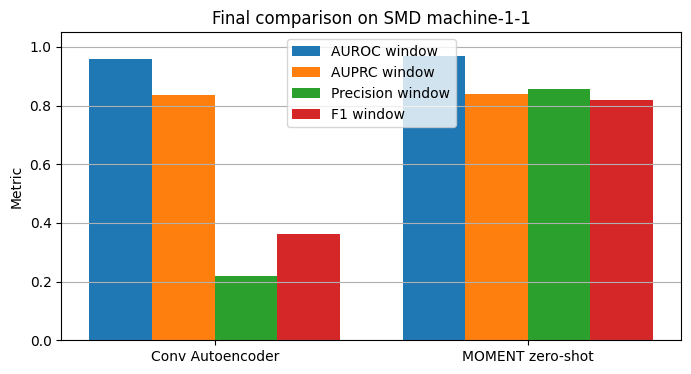

In [61]:
plt.figure(figsize=(8, 4))

x = np.arange(len(final_results))
width = 0.2

plt.bar(x - 1.5 * width, final_results["AUROC window"], width, label="AUROC window")
plt.bar(x - 0.5 * width, final_results["AUPRC window"], width, label="AUPRC window")
plt.bar(x + 0.5 * width, final_results["Precision window"], width, label="Precision window")
plt.bar(x + 1.5 * width, final_results["F1 window"], width, label="F1 window")

plt.xticks(x, final_results["Method"])
plt.ylim(0, 1.05)
plt.title("Final comparison on SMD machine-1-1")
plt.ylabel("Metric")
plt.legend()
plt.grid(axis="y")
plt.show()